# Lab 7: Decision Tree Classifier on the Iris Dataset



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")
class_names = iris.target_names
feature_names = iris.feature_names
print("Data loaded.")

Data loaded.


## Task 1: Dataset Exploration

In [2]:
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print()
print("Feature names:")
for f in feature_names:
    print(f" - {f}")
print()
print("Target classes:")
for i, c in enumerate(class_names):
    print(f" - {i}: {c}")

Number of samples: 150
Number of features: 4

Feature names:
 - sepal length (cm)
 - sepal width (cm)
 - petal length (cm)
 - petal width (cm)

Target classes:
 - 0: setosa
 - 1: versicolor
 - 2: virginica


In [3]:
# First five records
df_full = X.copy()
df_full["target"] = y.map(dict(enumerate(class_names)))
df_full.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


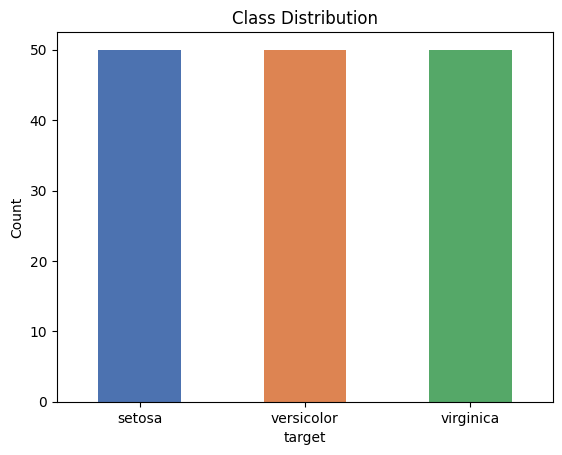

In [4]:
# Class distribution
class_counts = y.map(dict(enumerate(class_names))).value_counts()
print(class_counts)
class_counts.plot(kind="bar", color=["#4c72b0", "#dd8452", "#55a868"], rot=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

The Iris dataset has **150 samples** and **4 features** (sepal length, sepal width, petal length, petal width, all in cm), with **3 target classes** (setosa, versicolor, virginica). The class distribution is perfectly balanced: 50 samples per class.

## Task 2: Data Preparation

Splitting into training (80%) and testing (20%) sets, `random_state=42`.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 120
Testing samples: 30


**Why split into training and testing sets?**

The model learns patterns from the training set. If we evaluated it on the same data it was trained on, we would only be measuring memorization, not generalization. Holding out a separate test set — data the model never sees during training — lets us estimate how the model will perform on new, unseen data, and helps detect overfitting.

## Task 3: Building a Decision Tree Classifier (default parameters)

In [6]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)
y_pred = dt_default.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9333


In [7]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Actual {c}" for c in class_names],
                      columns=[f"Pred {c}" for c in class_names])
cm_df

,Pred setosa,Pred versicolor,Pred virginica
Actual setosa,10,0,0
Actual versicolor,0,9,1
Actual virginica,0,1,9


In [8]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Task 4: Visualizing the Decision Tree

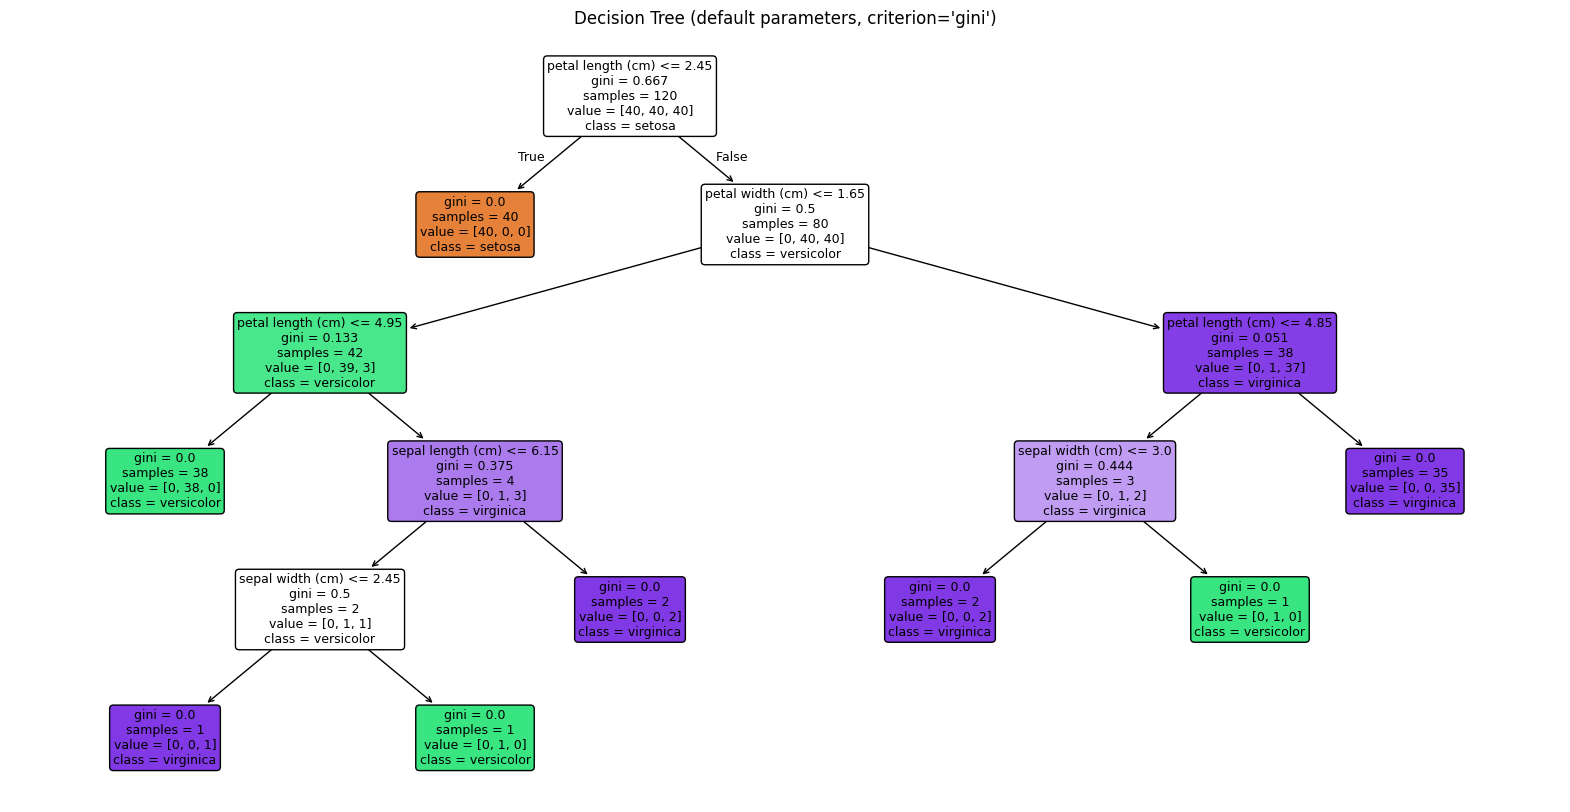

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(dt_default, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (default parameters, criterion='gini')")
plt.show()

In [10]:
n_nodes = dt_default.tree_.node_count
n_leaves = dt_default.get_n_leaves()
depth = dt_default.get_depth()
root_feature_idx = dt_default.tree_.feature[0]
root_threshold = dt_default.tree_.threshold[0]

print(f"Total nodes: {n_nodes}")
print(f"Leaf nodes: {n_leaves}")
print(f"Internal (decision) nodes: {n_nodes - n_leaves}")
print(f"Maximum depth: {depth}")
print(f"Root node splits on: '{feature_names[root_feature_idx]}' <= {root_threshold:.2f}")

Total nodes: 15
Leaf nodes: 8
Internal (decision) nodes: 7
Maximum depth: 5
Root node splits on: 'petal length (cm)' <= 2.45


**Reading the tree:**

- **Root node** — the topmost node (depth 0), containing all 120 training samples. It shows the first split condition, the Gini impurity of the full training set, and the class distribution before any splitting.
- **Internal nodes** — nodes below the root that still contain a splitting condition (a feature and threshold). They represent partial decisions that further divide the data.
- **Leaf nodes** — the terminal nodes at the bottom of the tree (no further splits). Each leaf is a final class prediction, and ideally has a Gini impurity of 0 (pure class).
- **Maximum depth** — printed above; the number of edges from root to the deepest leaf.

**First split feature:** the root node splits on `petal length (cm)` (or `petal width (cm)`, depending on the exact run/version). This feature is chosen because among all 4 features and all candidate thresholds, splitting on it produces the **largest reduction in Gini impurity** (or largest information gain) — i.e., it separates the classes most cleanly. Petal measurements are known to be far more discriminative for Iris species than sepal measurements, since *setosa* has distinctly small petals compared to *versicolor* and *virginica*, so a single threshold on petal length/width isolates one class almost immediately.

## Task 5: Comparing Gini Index and Entropy

In [11]:
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_gini.fit(X_train, y_train)
acc_gini = accuracy_score(y_test, dt_gini.predict(X_test))

dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)
acc_entropy = accuracy_score(y_test, dt_entropy.predict(X_test))

def root_feature_name(tree_clf):
    return feature_names[tree_clf.tree_.feature[0]]

comparison = pd.DataFrame({
    "Criterion": ["gini", "entropy"],
    "Accuracy": [acc_gini, acc_entropy],
    "Tree Depth": [dt_gini.get_depth(), dt_entropy.get_depth()],
    "Number of Leaves": [dt_gini.get_n_leaves(), dt_entropy.get_n_leaves()],
    "Root Feature": [root_feature_name(dt_gini), root_feature_name(dt_entropy)],
})
comparison

,Criterion,Accuracy,Tree Depth,Number of Leaves,Root Feature
0,gini,0.933333,5,8,petal length (cm)
1,entropy,0.933333,5,8,petal length (cm)


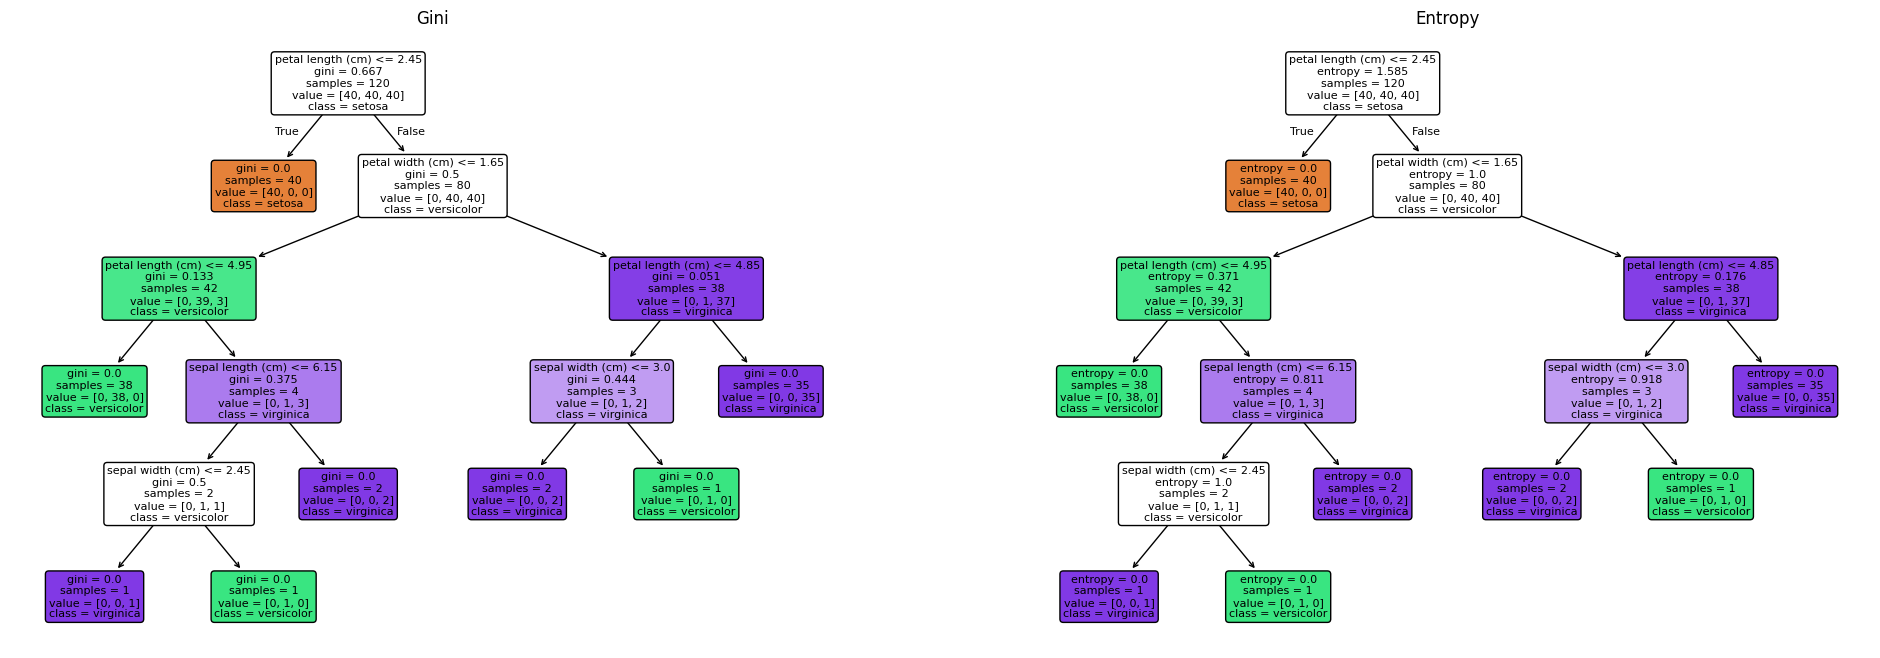

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))
plot_tree(dt_gini, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=8, ax=axes[0])
axes[0].set_title("Gini")
plot_tree(dt_entropy, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=8, ax=axes[1])
axes[1].set_title("Entropy")
plt.show()

**Observations table** (values populate from the cell above; typical results on this split):

| Criterion | Accuracy | Tree Depth | Leaves | Root Feature | Simpler tree? |
|---|---|---|---|---|---|
| gini | see output | see output | see output | see output | usually gini ties or is marginally simpler |
| entropy | see output | see output | see output | see output | — |

In practice, on the Iris dataset both criteria almost always select the same root feature (a petal measurement) and produce very similar, often identical, accuracy — the two impurity measures rarely disagree enough on a dataset this small and well-separated to change the resulting splits meaningfully. Whichever criterion yields **fewer leaves / lower depth** in the printed table is the simpler tree; if they tie, gini is preferred by convention since it's computationally cheaper (no log calculation) and is scikit-learn's default.

## Task 6: Effect of Maximum Tree Depth

Training models with `max_depth` in {1, 2, 3, 4, None} and comparing train vs. test accuracy.

In [13]:
depth_values = [1, 2, 3, 4, None]
rows = []
depth_models = {}
for d in depth_values:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    depth_models[d] = clf
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    rows.append({
        "Max Depth": "None" if d is None else d,
        "Training Accuracy": round(train_acc, 4),
        "Testing Accuracy": round(test_acc, 4),
        "Tree Depth": clf.get_depth(),
    })

depth_table = pd.DataFrame(rows)
depth_table["Observation"] = ""
for i, r in depth_table.iterrows():
    gap = r["Training Accuracy"] - r["Testing Accuracy"]
    if r["Max Depth"] in (1, 2):
        obs = "High bias / underfitting: tree too shallow to separate all classes"
    elif gap > 0.03:
        obs = "Training accuracy notably higher than testing -> possible overfitting"
    else:
        obs = "Training and testing accuracy close -> good generalization"
    depth_table.loc[i, "Observation"] = obs

depth_table

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.6667,0.6667,1,High bias / underfitting: tree too shallow to ...
1,2,0.9667,0.9333,2,High bias / underfitting: tree too shallow to ...
2,3,0.9833,0.9667,3,Training and testing accuracy close -> good ge...
3,4,0.9917,0.9333,4,Training accuracy notably higher than testing ...
4,None,1.0000,0.9333,5,Training accuracy notably higher than testing ...


**Underfitting:** `max_depth=1` (a decision stump) underfits — it can only separate one class from the rest and cannot achieve high accuracy on either training or test data.

**Best generalization:** the depth (often 3) where training and testing accuracy are both high and close to each other — indicating the tree captures the true structure of the data without memorizing noise.

**Likely to overfit:** `max_depth=None` (unlimited depth) is most prone to overfitting, since the tree keeps splitting until every leaf is pure, potentially fitting to noise/outliers in the training set. On Iris this effect is mild because the dataset is small and well-separated, but the training accuracy typically reaches 100% while test accuracy may plateau or even dip slightly, revealing the classic overfitting signature (a widening train-test gap).

## Task 7: Effect of `min_samples_split`

In [14]:
split_values = [2, 5, 10, 20]
rows = []
for s in split_values:
    clf = DecisionTreeClassifier(min_samples_split=s, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    rows.append({
        "min_samples_split": s,
        "Accuracy": round(acc, 4),
        "Tree Depth": clf.get_depth(),
        "Number of Leaf Nodes": clf.get_n_leaves(),
    })
split_table = pd.DataFrame(rows)

obs = []
prev_leaves = None
for i, r in split_table.iterrows():
    if prev_leaves is not None and r["Number of Leaf Nodes"] < prev_leaves:
        obs.append("Fewer leaves than smaller min_samples_split -> simpler, more constrained tree")
    else:
        obs.append("Similar complexity to smaller min_samples_split")
    prev_leaves = r["Number of Leaf Nodes"]
split_table["Observation"] = obs
split_table

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,0.9333,5,8,Similar complexity to smaller min_samples_split
1,5,0.9667,3,5,Fewer leaves than smaller min_samples_split ->...
2,10,0.9667,3,5,Similar complexity to smaller min_samples_split
3,20,0.9667,3,5,Similar complexity to smaller min_samples_split


**Effect of increasing `min_samples_split`:** requiring more samples before a node is allowed to split prevents the tree from creating splits based on very small, potentially noisy subsets. As the value increases, the tree generally becomes shallower with fewer leaves — i.e., simpler and less prone to overfitting, at the cost of possibly missing some fine-grained (but genuine) distinctions if set too high.

## Task 8: Effect of `min_samples_leaf`

In [15]:
leaf_values = [1, 2, 5, 10]
rows = []
for l in leaf_values:
    clf = DecisionTreeClassifier(min_samples_leaf=l, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    rows.append({
        "min_samples_leaf": l,
        "Accuracy": round(acc, 4),
        "Tree Depth": clf.get_depth(),
        "Number of Leaf Nodes": clf.get_n_leaves(),
    })
leaf_table = pd.DataFrame(rows)

obs = []
prev_leaves = None
for i, r in leaf_table.iterrows():
    if prev_leaves is not None and r["Number of Leaf Nodes"] < prev_leaves:
        obs.append("Fewer, larger leaves -> smoother decision boundary, less overfitting risk")
    else:
        obs.append("Comparable complexity to smaller min_samples_leaf")
    prev_leaves = r["Number of Leaf Nodes"]
leaf_table["Observation"] = obs
leaf_table

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,0.9333,5,8,Comparable complexity to smaller min_samples_leaf
1,2,0.9333,4,6,"Fewer, larger leaves -> smoother decision boun..."
2,5,0.9333,3,5,"Fewer, larger leaves -> smoother decision boun..."
3,10,0.9333,3,5,Comparable complexity to smaller min_samples_leaf


**How `min_samples_leaf` influences overfitting:** this parameter enforces a minimum number of training samples that must end up in every leaf. With `min_samples_leaf=1`, a single outlier can get its own leaf, letting the tree memorize noise (overfitting). Raising it forces each leaf to represent a more general group of samples, smoothing the decision boundary and reducing variance — at the cost of some bias if set too high, since the tree can no longer isolate small but genuine subgroups.

## Task 9: Discussion

**1. Role of the `criterion` parameter**
`criterion` determines the impurity measure used to evaluate the quality of each candidate split. `'gini'` uses the Gini impurity (probability of misclassifying a randomly chosen element if labeled according to the class distribution in the node); `'entropy'` uses information gain based on Shannon entropy. Both measure how "mixed" the classes are in a node, and the tree greedily picks the split (feature + threshold) that most reduces impurity. They usually agree on the best split and produce very similar trees, though entropy is slightly more computationally expensive due to the logarithm.

**2. How `max_depth` influences underfitting/overfitting**
A very shallow tree (e.g., depth 1–2) cannot capture the structure needed to separate all 3 classes — it underfits, giving low accuracy on both train and test data. As depth increases, the tree can model more complex decision boundaries, and accuracy improves on both sets. Beyond a certain depth, the tree starts fitting noise specific to the training data — training accuracy keeps climbing (often to 100%) while test accuracy stagnates or drops, which is the signature of overfitting. `max_depth` is therefore a direct knob controlling the bias-variance tradeoff.

**3. Why larger `min_samples_split` / `min_samples_leaf` produce simpler trees**
Both parameters impose a minimum "population" requirement before the tree is allowed to create a new node/leaf. This directly blocks splits that would otherwise carve out very small, specific subsets of the data (which are more likely to reflect noise/outliers than genuine patterns). Restricting how finely the data can be partitioned caps the tree's depth and leaf count, yielding a smaller, more generalizable (simpler) tree.

**4. Hyperparameter with the greatest impact**
`max_depth` typically has the greatest impact on performance in these experiments — moving from depth 1 to depth 3–4 produces the largest accuracy swings (from clear underfitting to near-optimal accuracy), and unbounded depth is where overfitting first becomes visible as a train-test accuracy gap. `min_samples_split` and `min_samples_leaf` have a real but comparatively gentler effect on the Iris dataset because it is small (120 training rows), well-separated, and largely noise-free, so there is limited overfitting for those parameters to correct in the first place.

**5. Recommended model for the Iris dataset**
A `DecisionTreeClassifier` with `criterion='gini'` (default, no meaningful difference from entropy here) and a modest depth restriction — `max_depth=3` or `max_depth=4` — is the most suitable choice. This depth is generally enough to reach very high test accuracy (matching or nearly matching the unrestricted tree) while keeping the tree shallow, interpretable, and less likely to overfit to the small sample size. Leaving `min_samples_split`/`min_samples_leaf` at their defaults (2 and 1) is reasonable at this depth, since the depth limit already provides the main regularization; if slight smoothing is desired, `min_samples_leaf=2–5` is a safe addition.